# Loss Function Swap Experiment: PRMP vs Standard GNN on F1 Data

This notebook demonstrates the **Predictive Residual Message Passing (PRMP)** loss function swap experiment.
It compares Standard GNN and PRMP models on 4 task configurations using the Ergast F1 heterogeneous graph:

1. **Config 1 - Natural Regression**: mean finishing position, MAE loss
2. **Config 2 - Binned Classification**: position binned into 5 quantiles, CrossEntropy loss
3. **Config 3 - Natural Classification**: DNF (Did Not Finish) binary, BCE loss
4. **Config 4 - Softened Regression**: DNF fraction (continuous), MSE loss

The experiment tests whether PRMP's regression advantage stems from the **loss function type** (regression vs classification) or the **target variable nature** (continuous position vs binary DNF).

**Key finding**: Mixed evidence — PRMP improves natural regression (MAE ~4.0 vs ~5.0) but hurts binned classification (accuracy ~0.25 vs ~0.53).

In [1]:
import subprocess, sys
def _pip(*a): subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *a])

# Packages NOT pre-installed on Colab — always install
_pip('loguru', 'psutil')

# Core packages — pre-installed on Colab, install locally to match Colab env
if 'google.colab' not in sys.modules:
    _pip('numpy==2.0.2', 'pandas==2.2.2', 'matplotlib==3.10.0')
    # scipy/sklearn versions depend on Python version
    try:
        _pip('scipy==1.16.3', 'scikit-learn==1.6.1')
    except Exception:
        _pip('scipy', 'scikit-learn')

# Optional: torch + torch_geometric for live training (skip if not available)
TORCH_AVAILABLE = False
try:
    import torch
    TORCH_AVAILABLE = True
except ImportError:
    try:
        if 'google.colab' not in sys.modules:
            _pip('torch', '--index-url', 'https://download.pytorch.org/whl/cpu')
        _pip('torch-geometric')
        import torch
        TORCH_AVAILABLE = True
    except Exception:
        print('torch/torch_geometric not available — running analysis-only mode')

if TORCH_AVAILABLE:
    try:
        from torch_geometric.data import HeteroData
        TORCH_AVAILABLE = True
    except ImportError:
        try:
            _pip('torch-geometric')
            from torch_geometric.data import HeteroData
        except Exception:
            TORCH_AVAILABLE = False
            print('torch_geometric not available — running analysis-only mode')

print(f'torch available: {TORCH_AVAILABLE}')


[notice] A new release of pip is available: 23.0.1 -> 26.0.1
[notice] To update, run: python3 -m pip install --upgrade pip



[notice] A new release of pip is available: 23.0.1 -> 26.0.1
[notice] To update, run: python3 -m pip install --upgrade pip


ERROR: Ignored the following versions that require a different python version: 1.16.0 Requires-Python >=3.11; 1.16.0rc1 Requires-Python >=3.11; 1.16.0rc2 Requires-Python >=3.11; 1.16.1 Requires-Python >=3.11; 1.16.2 Requires-Python >=3.11; 1.16.3 Requires-Python >=3.11; 1.17.0 Requires-Python >=3.11; 1.17.0rc1 Requires-Python >=3.11; 1.17.0rc2 Requires-Python >=3.11; 1.17.1 Requires-Python >=3.11; 1.6.2 Requires-Python >=3.7,<3.10; 1.6.3 Requires-Python >=3.7,<3.10; 1.7.0 Requires-Python >=3.7,<3.10; 1.7.1 Requires-Python >=3.7,<3.10
ERROR: Could not find a version that satisfies the requirement scipy==1.16.3 (from versions: 0.8.0, 0.9.0, 0.10.0, 0.10.1, 0.11.0, 0.12.0, 0.12.1, 0.13.0, 0.13.1, 0.13.2, 0.13.3, 0.14.0, 0.14.1, 0.15.0, 0.15.1, 0.16.0, 0.16.1, 0.17.0, 0.17.1, 0.18.0, 0.18.1, 0.19.0, 0.19.1, 1.0.0, 1.0.1, 1.1.0, 1.2.0, 1.2.1, 1.2.2, 1.2.3, 1.3.0, 1.3.1, 1.3.2, 1.3.3, 1.4.0, 1.4.1, 1.5.0, 1.5.1, 1.5.2, 1.5.3, 1.5.4, 1.6.0, 1.6.1, 1.7.2, 1.7.3, 1.8.0rc1, 1.8.0rc2, 1.8.0rc3, 1


[notice] A new release of pip is available: 23.0.1 -> 26.0.1
[notice] To update, run: python3 -m pip install --upgrade pip



[notice] A new release of pip is available: 23.0.1 -> 26.0.1
[notice] To update, run: python3 -m pip install --upgrade pip



[notice] A new release of pip is available: 23.0.1 -> 26.0.1
[notice] To update, run: python3 -m pip install --upgrade pip


/tmp/nb_test_env/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


torch available: True


In [2]:
import json
import sys
import os
import math
import gc
import time
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.metrics import mean_absolute_error, accuracy_score, r2_score

from loguru import logger
logger.remove()
logger.add(sys.stdout, level="INFO", format="{time:HH:mm:ss}|{level:<7}|{message}")

warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=FutureWarning)

print('Imports loaded successfully')

Imports loaded successfully


In [3]:
# Load pre-computed results from the full experiment
GITHUB_DATA_URL = "https://raw.githubusercontent.com/ai-inventor-outputs/ai-invention-b2d5b0-predictive-residual-message-passing-filt/main/experiment_iter6_loss_function_s/demo/mini_demo_data.json"

def load_data():
    try:
        import urllib.request
        with urllib.request.urlopen(GITHUB_DATA_URL) as response:
            return json.loads(response.read().decode())
    except Exception: pass
    if os.path.exists("mini_demo_data.json"):
        with open("mini_demo_data.json") as f: return json.load(f)
    raise FileNotFoundError("Could not load mini_demo_data.json")

In [4]:
data = load_data()
print(f"Loaded pre-computed results: {len(data['datasets'][0]['examples'])} examples")
print(f"Configs: {data['metadata']['configs']}")
print(f"Full experiment: {data['metadata']['description']}")
print(f"Conclusion: {data['metadata']['analysis']['conclusion']}")

Loaded pre-computed results: 12 examples
Configs: ['config1_natural_regression', 'config2_binned_classification', 'config3_natural_classification', 'config4_softened_regression']
Full experiment: Controlled experiment: 4 configs x 2 methods x 13 seeds = 104 runs
Conclusion: Mixed


In [5]:
# ── Configuration ─────────────────────────────────────────────────────────
# Tunable parameters for live training (if torch available)
HIDDEN_DIM = 32        # Original: 128
NUM_LAYERS = 1         # Original: 2
LR = 0.001
WEIGHT_DECAY = 1e-5
EPOCHS = 10            # Original: 80
SEEDS = [42]           # Original: [42, 123, 7, 0, 1, 2, 3, 10, 21, 55, 77, 99, 256]
PATIENCE = 5           # Original: 15

ERGAST_CSV_URL = "https://github.com/rubenv/ergast-mrd/raw/master/f1db_csv.zip"

# Tables used in the F1 heterogeneous graph
NODE_TABLES = ["drivers", "races", "constructors", "circuits", "status",
               "results", "qualifying", "driver_standings"]

ID_COLUMNS = {
    "circuits": ["circuitId"],
    "constructors": ["constructorId"],
    "drivers": ["driverId"],
    "driver_standings": ["driverStandingsId", "raceId", "driverId"],
    "qualifying": ["qualifyId", "raceId", "driverId", "constructorId"],
    "races": ["raceId", "circuitId"],
    "results": ["resultId", "raceId", "driverId", "constructorId", "statusId"],
    "status": ["statusId"],
}

# FK links for building graph edges
GRAPH_FK_LINKS = [
    ("results", "raceId", "races", "raceId"),
    ("results", "driverId", "drivers", "driverId"),
    ("results", "constructorId", "constructors", "constructorId"),
    ("results", "statusId", "status", "statusId"),
    ("qualifying", "raceId", "races", "raceId"),
    ("qualifying", "driverId", "drivers", "driverId"),
    ("qualifying", "constructorId", "constructors", "constructorId"),
    ("races", "circuitId", "circuits", "circuitId"),
    ("driver_standings", "raceId", "races", "raceId"),
    ("driver_standings", "driverId", "drivers", "driverId"),
]

print(f"Config: HIDDEN_DIM={HIDDEN_DIM}, NUM_LAYERS={NUM_LAYERS}, EPOCHS={EPOCHS}, SEEDS={SEEDS}")

Config: HIDDEN_DIM=32, NUM_LAYERS=1, EPOCHS=10, SEEDS=[42]


## Phase 0-1: Data Loading & Heterogeneous Graph Construction

Download the Ergast F1 CSV database, encode tables to numeric features, and build a heterogeneous PyTorch Geometric graph with foreign-key edges between entity tables (drivers, races, constructors, circuits, etc.).

In [6]:
import zipfile, io, csv as csv_mod

def sanitize_for_json(obj):
    """Recursively replace NaN/Inf with None for valid JSON."""
    if isinstance(obj, dict):
        return {k: sanitize_for_json(v) for k, v in obj.items()}
    if isinstance(obj, list):
        return [sanitize_for_json(v) for v in obj]
    if isinstance(obj, float):
        if math.isnan(obj) or math.isinf(obj):
            return None
        return obj
    if isinstance(obj, (np.floating, np.integer)):
        v = float(obj)
        if math.isnan(v) or math.isinf(v):
            return None
        return v
    return obj


def download_ergast_csv():
    """Download and extract CSV tables from Ergast F1 database."""
    import requests
    local_zip = "f1db_csv.zip"
    if not os.path.exists(local_zip):
        logger.info("Downloading Ergast F1 CSV...")
        resp = requests.get(ERGAST_CSV_URL, timeout=120)
        resp.raise_for_status()
        with open(local_zip, 'wb') as f:
            f.write(resp.content)

    tables = {}
    with zipfile.ZipFile(local_zip, "r") as zf:
        for csv_name in sorted(zf.namelist()):
            if not csv_name.endswith(".csv"):
                continue
            tname = csv_name.replace(".csv", "")
            if tname not in NODE_TABLES:
                continue
            with zf.open(csv_name) as f:
                raw = f.read().decode("utf-8")
                lines = raw.strip().split("\n")
                header_fields = next(csv_mod.reader([lines[0]]))
                if len(lines) > 1:
                    data_fields = next(csv_mod.reader([lines[1]]))
                    if len(data_fields) > len(header_fields):
                        extra = len(data_fields) - len(header_fields)
                        for ei in range(extra):
                            header_fields.append(f"_extra_{ei}")
                        lines[0] = ",".join(header_fields)
                        raw = "\n".join(lines)
                df = pd.read_csv(
                    io.StringIO(raw),
                    na_values=["\\N", "NULL", ""],
                    engine="python",
                )
            for col in df.columns:
                s = df[col]
                dtype_str = str(type(s.dtype))
                if "Arrow" in dtype_str or "arrow" in dtype_str:
                    num = pd.to_numeric(s, errors="coerce")
                    if num.notna().sum() > len(num) * 0.5 and s.notna().sum() > 0:
                        df[col] = num
                    else:
                        df[col] = s.astype(object)
            for col in ID_COLUMNS.get(tname, []):
                if col in df.columns:
                    df[col] = pd.to_numeric(df[col], errors="coerce")
            tables[tname] = df
    logger.info(f"Loaded {len(tables)} tables: {list(tables.keys())}")
    return tables


def encode_table(df, table_name):
    """Encode table to numeric features."""
    id_cols = set(ID_COLUMNS.get(table_name, []))
    encoded = df.copy()
    for col in encoded.columns:
        if encoded[col].dtype == "object":
            try:
                dt = pd.to_datetime(encoded[col], format="mixed", errors="coerce")
                if dt.notna().sum() > len(dt) * 0.5:
                    encoded[col] = dt.astype("int64") // 10**9
                    encoded[col] = encoded[col].where(dt.notna(), -1)
                    continue
            except Exception:
                pass
            codes, _ = pd.factorize(encoded[col], sort=False)
            encoded[col] = codes.astype(np.float32)
            continue
        if pd.api.types.is_numeric_dtype(encoded[col]):
            encoded[col] = encoded[col].fillna(-1).astype(np.float32)
        else:
            codes, _ = pd.factorize(encoded[col].astype(str), sort=False)
            encoded[col] = codes.astype(np.float32)

    feat_cols = [c for c in encoded.columns if c not in id_cols]
    if not feat_cols:
        return np.ones((len(encoded), 1), dtype=np.float32), ["_dummy"]
    arr = encoded[feat_cols].values.astype(np.float32)
    mu = np.nanmean(arr, axis=0)
    std = np.nanstd(arr, axis=0) + 1e-8
    arr = (arr - mu) / std
    arr = np.nan_to_num(arr, nan=0.0)
    return arr, feat_cols


if TORCH_AVAILABLE:
    import torch
    import torch.nn as nn
    import torch.nn.functional as F
    from torch_geometric.data import HeteroData
    from torch_geometric.nn import HeteroConv, SAGEConv, LayerNorm
    from sklearn.metrics import roc_auc_score, average_precision_score

    HAS_GPU = torch.cuda.is_available()
    DEVICE = torch.device("cuda" if HAS_GPU else "cpu")

    def build_hetero_graph(tables):
        """Build HeteroData graph using vectorized operations."""
        hetero_data = HeteroData()
        id_maps = {}
        graph_stats = {}

        for tname in NODE_TABLES:
            if tname not in tables:
                continue
            df = tables[tname]
            pk = ID_COLUMNS.get(tname, [None])[0]

            if pk and pk in df.columns:
                unique_ids = df[pk].dropna().unique().astype(int)
                imap = {int(v): i for i, v in enumerate(unique_ids)}
            else:
                imap = {i: i for i in range(len(df))}
            id_maps[tname] = imap

            feat_arr, feat_cols = encode_table(df, tname)
            if pk and pk in df.columns and len(df) > len(imap):
                imap = {i: i for i in range(len(df))}
                id_maps[tname] = imap
                hetero_data[tname].x = torch.tensor(feat_arr, dtype=torch.float32)
            else:
                hetero_data[tname].x = torch.tensor(feat_arr[:len(imap)], dtype=torch.float32)

            hetero_data[tname].num_nodes = len(imap)
            graph_stats[tname] = len(imap)

        edge_count = 0
        for child_t, child_col, parent_t, parent_col in GRAPH_FK_LINKS:
            if child_t not in tables or parent_t not in tables:
                continue
            child_df = tables[child_t]
            if child_col not in child_df.columns:
                continue
            child_imap = id_maps[child_t]
            parent_imap = id_maps[parent_t]
            fk_series = pd.to_numeric(child_df[child_col], errors="coerce")
            fk_vals = fk_series.values
            valid_mask = ~pd.isna(fk_vals)
            fk_valid = fk_vals[valid_mask].astype(int)
            child_row_indices = np.arange(len(child_df))[valid_mask]
            child_idx_map = dict(zip(child_imap.keys(), child_imap.values()))
            parent_idx_map = dict(zip(parent_imap.keys(), parent_imap.values()))
            src_arr = np.array([child_idx_map.get(int(c), -1) for c in child_row_indices])
            dst_arr = np.array([parent_idx_map.get(int(f), -1) for f in fk_valid])
            both_valid = (src_arr >= 0) & (dst_arr >= 0)
            if not both_valid.any():
                continue
            src_t = torch.tensor(src_arr[both_valid], dtype=torch.long)
            dst_t = torch.tensor(dst_arr[both_valid], dtype=torch.long)
            et_fwd = (child_t, f"fk_{child_col}", parent_t)
            hetero_data[et_fwd].edge_index = torch.stack([src_t, dst_t], dim=0)
            et_rev = (parent_t, f"rev_{child_col}", child_t)
            hetero_data[et_rev].edge_index = torch.stack([dst_t, src_t], dim=0)
            edge_count += int(both_valid.sum())

        graph_stats["total_edges"] = edge_count
        logger.info(f"Graph: {sum(v for k,v in graph_stats.items() if k != 'total_edges')} nodes, {edge_count} edges")
        return hetero_data, id_maps, graph_stats

    print(f"Device: {DEVICE}")
else:
    print("Skipping graph construction (torch not available) — using pre-computed results")

Device: cpu


## Phase 2-3: Target Labels & Model Architecture

The experiment uses 4 target configurations from the same F1 data:
- **C1**: Natural regression — mean finishing position with L1Loss (MAE)
- **C2**: Binned classification — position quantized into 5 bins with CrossEntropyLoss
- **C3**: Natural classification — binary DNF (Did Not Finish) with BCEWithLogitsLoss
- **C4**: Softened regression — DNF fraction (continuous 0-1) with MSELoss

The **PRMPConv** layer predicts incoming messages, computes residuals, and aggregates them. The **F1HeteroGNN** wraps either Standard (SAGEConv) or PRMP convolutions.

In [7]:
if TORCH_AVAILABLE:
    def build_targets(tables, id_maps):
        """Build target labels for 4 task configurations."""
        results = tables["results"]
        races = tables["races"]
        drivers_map = id_maps["drivers"]
        num_drivers = len(drivers_map)
        races = races.copy()
        if "date" in races.columns:
            races["_date"] = pd.to_datetime(races["date"].astype(str), format="mixed", errors="coerce")
        else:
            races["_date"] = pd.RangeIndex(len(races))
        results = results.copy()
        results["raceId"] = pd.to_numeric(results["raceId"], errors="coerce").astype("float64")
        results["driverId"] = pd.to_numeric(results["driverId"], errors="coerce").astype("float64")
        if "statusId" in results.columns:
            results["statusId"] = pd.to_numeric(results["statusId"], errors="coerce").astype("float64")
        races["raceId"] = pd.to_numeric(races["raceId"], errors="coerce").astype("float64")
        results_m = results.merge(races[["raceId", "_date"]], on="raceId", how="inner").sort_values("_date")
        pos_col = "positionOrder" if "positionOrder" in results_m.columns else "position"
        results_m["_pos"] = pd.to_numeric(results_m[pos_col], errors="coerce")
        race_dates = races[["raceId", "_date"]].dropna(subset=["_date"]).sort_values("_date")
        n_races = len(race_dates)
        cutoff_train = race_dates.iloc[int(n_races * 0.7)]["_date"]
        cutoff_val = race_dates.iloc[int(n_races * 0.8)]["_date"]
        driver_ids_train = set(results_m[results_m["_date"] <= cutoff_train]["driverId"].dropna().unique())
        driver_ids_val = set(results_m[(results_m["_date"] > cutoff_train) & (results_m["_date"] <= cutoff_val)]["driverId"].dropna().unique())
        driver_ids_test = set(results_m[results_m["_date"] > cutoff_val]["driverId"].dropna().unique())
        use_random = len(driver_ids_test) < 50

        def make_masks(valid_mask_tensor):
            if use_random:
                valid_idx = valid_mask_tensor.nonzero(as_tuple=True)[0].numpy()
                rng = np.random.RandomState(42)
                rng.shuffle(valid_idx)
                n = len(valid_idx)
                nt, nv = int(n * 0.7), int(n * 0.15)
                tr = torch.zeros(num_drivers, dtype=torch.bool)
                va = torch.zeros(num_drivers, dtype=torch.bool)
                te = torch.zeros(num_drivers, dtype=torch.bool)
                tr[valid_idx[:nt]] = True
                va[valid_idx[nt:nt+nv]] = True
                te[valid_idx[nt+nv:]] = True
                return tr, va, te
            else:
                tr = torch.zeros(num_drivers, dtype=torch.bool)
                va = torch.zeros(num_drivers, dtype=torch.bool)
                te = torch.zeros(num_drivers, dtype=torch.bool)
                for did, idx in drivers_map.items():
                    if not valid_mask_tensor[idx]: continue
                    if did in driver_ids_train: tr[idx] = True
                    if did in driver_ids_val: va[idx] = True
                    if did in driver_ids_test: te[idx] = True
                return tr, va, te

        configs = {}
        # C1: Natural Regression
        pos_agg = results_m.dropna(subset=["_pos"]).groupby("driverId")["_pos"].mean()
        pos_labels = torch.full((num_drivers,), float("nan"))
        valid_pos = torch.zeros(num_drivers, dtype=torch.bool)
        for did, idx in drivers_map.items():
            if did in pos_agg.index:
                pos_labels[idx] = float(pos_agg.loc[did])
                valid_pos[idx] = True
        c1_tr, c1_va, c1_te = make_masks(valid_pos)
        pos_clean = pos_labels.clone()
        pos_clean[torch.isnan(pos_clean)] = 0.0
        configs["config1_natural_regression"] = dict(
            labels=pos_clean, train_mask=c1_tr, val_mask=c1_va, test_mask=c1_te,
            loss_type="MAE", target_type="position", num_classes=1,
            description="Natural regression: mean position with L1Loss")
        # C2: Binned Classification
        train_vals = pos_clean[c1_tr].numpy()
        try:
            _, bin_edges = pd.qcut(train_vals, q=5, retbins=True, duplicates="drop")
        except ValueError:
            bin_edges = np.array([0, 5, 10, 15, 20, 30])
        num_bins = len(bin_edges) - 1
        bin_labels = torch.full((num_drivers,), 0, dtype=torch.long)
        for i in range(num_drivers):
            if valid_pos[i]:
                v = pos_labels[i].item()
                bi = min(np.searchsorted(bin_edges[1:], v, side="right"), num_bins - 1)
                bin_labels[i] = bi
        bin_centers = torch.tensor([(bin_edges[i]+bin_edges[i+1])/2 for i in range(num_bins)], dtype=torch.float32)
        configs["config2_binned_classification"] = dict(
            labels=bin_labels, train_mask=c1_tr, val_mask=c1_va, test_mask=c1_te,
            loss_type="CrossEntropy", target_type="position", num_classes=num_bins,
            bin_centers=bin_centers, bin_edges=bin_edges.tolist(),
            description=f"Binned classification: {num_bins}-class with CrossEntropyLoss")
        # C3: Natural Classification (DNF)
        dnf_labels = torch.full((num_drivers,), float("nan"))
        valid_dnf = torch.zeros(num_drivers, dtype=torch.bool)
        soft_labels = torch.full((num_drivers,), float("nan"))
        valid_soft = torch.zeros(num_drivers, dtype=torch.bool)
        if "statusId" in results_m.columns:
            results_m["_is_dnf"] = (results_m["statusId"] != 1).astype(float)
        else:
            results_m["_is_dnf"] = results_m["_pos"].isna().astype(float)
        dnf_agg = results_m.dropna(subset=["driverId"]).groupby("driverId")["_is_dnf"].agg(["max", "mean"])
        for did, idx in drivers_map.items():
            if did in dnf_agg.index:
                dnf_labels[idx] = 1.0 if dnf_agg.loc[did, "max"] > 0 else 0.0
                valid_dnf[idx] = True
                soft_labels[idx] = float(dnf_agg.loc[did, "mean"])
                valid_soft[idx] = True
        c3_tr, c3_va, c3_te = make_masks(valid_dnf)
        dnf_clean = dnf_labels.clone()
        dnf_clean[torch.isnan(dnf_clean)] = 0.0
        configs["config3_natural_classification"] = dict(
            labels=dnf_clean, train_mask=c3_tr, val_mask=c3_va, test_mask=c3_te,
            loss_type="BCE", target_type="binary", num_classes=1,
            description="Natural classification: DNF binary with BCEWithLogitsLoss")
        # C4: Softened Regression
        c4_tr, c4_va, c4_te = make_masks(valid_soft)
        soft_clean = soft_labels.clone()
        soft_clean[torch.isnan(soft_clean)] = 0.0
        configs["config4_softened_regression"] = dict(
            labels=soft_clean, train_mask=c4_tr, val_mask=c4_va, test_mask=c4_te,
            loss_type="MSE", target_type="binary", num_classes=1,
            description="Softened regression: DNF fraction with MSELoss")
        for cn, cfg in configs.items():
            logger.info(f"{cn}: train={cfg['train_mask'].sum()}, val={cfg['val_mask'].sum()}, test={cfg['test_mask'].sum()}")
        return configs

    class PRMPConv(nn.Module):
        """Predictive Residual Message Passing convolution for one edge type."""
        def __init__(self, in_dim, out_dim):
            super().__init__()
            self.pred_mlp = nn.Sequential(nn.Linear(in_dim, out_dim), nn.ReLU(), nn.Linear(out_dim, in_dim))
            nn.init.zeros_(self.pred_mlp[-1].weight)
            nn.init.zeros_(self.pred_mlp[-1].bias)
            self.ln = nn.LayerNorm(in_dim)
            self.update_lin = nn.Linear(in_dim * 2, out_dim)
            self.grad_pred, self.grad_main = [], []

        def forward(self, x_src, x_dst, edge_index):
            src_idx, dst_idx = edge_index[0], edge_index[1]
            x_j = x_src[src_idx]
            predicted = self.pred_mlp(x_dst[dst_idx].detach())
            residual = self.ln(x_j - predicted)
            if self.training and residual.requires_grad:
                predicted.register_hook(lambda g: self.grad_pred.append(g.norm().item()))
                x_j.register_hook(lambda g: self.grad_main.append(g.norm().item()))
            num_dst = x_dst.shape[0]
            aggr = torch.zeros(num_dst, residual.shape[1], device=residual.device)
            cnt = torch.zeros(num_dst, 1, device=residual.device)
            aggr.scatter_add_(0, dst_idx.unsqueeze(1).expand_as(residual), residual)
            cnt.scatter_add_(0, dst_idx.unsqueeze(1), torch.ones(len(dst_idx), 1, device=residual.device))
            aggr = aggr / cnt.clamp(min=1)
            return self.update_lin(torch.cat([x_dst, aggr], dim=-1))

    class F1HeteroGNN(nn.Module):
        """Heterogeneous GNN with Standard (SAGEConv) or PRMP convolutions."""
        def __init__(self, feat_dims, hidden, n_layers, edge_types, conv_type="standard", num_classes=1):
            super().__init__()
            self.conv_type = conv_type
            self.n_layers = n_layers
            self.encs = nn.ModuleDict({nt: nn.Sequential(nn.Linear(fd, hidden), nn.ReLU()) for nt, fd in feat_dims.items()})
            self.convs = nn.ModuleList()
            self.lns = nn.ModuleList()
            for _ in range(n_layers):
                cd = {}
                for et in edge_types:
                    cd[et] = PRMPConv(hidden, hidden) if conv_type == "prmp" else SAGEConv((hidden, hidden), hidden)
                self.convs.append(HeteroConv(cd, aggr="sum"))
                self.lns.append(nn.ModuleDict({nt: LayerNorm(hidden) for nt in feat_dims}))
            self.head = nn.Sequential(nn.Linear(hidden, hidden // 2), nn.ReLU(), nn.Dropout(0.3), nn.Linear(hidden // 2, num_classes))

        def forward(self, x_dict, edge_index_dict):
            h = {nt: self.encs[nt](x) if nt in self.encs else x for nt, x in x_dict.items()}
            for i in range(self.n_layers):
                if self.conv_type == "prmp":
                    new_h = self._prmp_fwd(h, edge_index_dict, i)
                else:
                    new_h = self.convs[i](h, edge_index_dict)
                for nt in h:
                    if nt in new_h and nt in self.lns[i]:
                        new_h[nt] = F.relu(self.lns[i][nt](new_h[nt])) + h[nt]
                h = {k: new_h.get(k, h[k]) for k in h}
            return self.head(h["drivers"])

        def _prmp_fwd(self, h, eid, layer_i):
            new_h = {}
            cl = self.convs[layer_i]
            for et, ei in eid.items():
                src_t, _, dst_t = et
                if src_t not in h or dst_t not in h: continue
                k = "__".join(et)
                if k in cl.convs:
                    out = cl.convs[k](h[src_t], h[dst_t], ei)
                    new_h[dst_t] = new_h.get(dst_t, torch.zeros_like(h[dst_t])) + out
            return new_h

        def collect_grad_norms(self):
            pn, mn = [], []
            for cl in self.convs:
                for c in cl.convs.values():
                    if isinstance(c, PRMPConv):
                        pn.extend(c.grad_pred); mn.extend(c.grad_main)
            return {"pred": pn, "main": mn}

        def clear_grad_norms(self):
            for cl in self.convs:
                for c in cl.convs.values():
                    if isinstance(c, PRMPConv):
                        c.grad_pred.clear(); c.grad_main.clear()

    print("Model classes defined (PRMPConv, F1HeteroGNN)")
else:
    print("Skipping model definitions (torch not available)")

Model classes defined (PRMPConv, F1HeteroGNN)


## Phase 4-5: Training & Experiment Loop

Each training run creates a fresh model (Standard or PRMP), trains with early stopping, and returns test metrics. When torch is available, we run a small-scale demo; otherwise we proceed to analysis of pre-computed results.

In [8]:
live_results = None

if TORCH_AVAILABLE:
    def _metric(out, labels, mask, lt, nc, cfg):
        if mask.sum() == 0: return 0.0
        p, t = out[mask].cpu(), labels[mask].cpu()
        if lt in ["MAE", "MSE"]: return float(mean_absolute_error(t.numpy(), p.squeeze(-1).numpy()))
        if lt == "CrossEntropy": return float(accuracy_score(t.numpy(), p.argmax(-1).numpy()))
        if lt == "BCE":
            pr = torch.sigmoid(p.squeeze(-1)).numpy()
            tg = t.numpy()
            if len(np.unique(tg)) < 2: return 0.5
            try: return float(roc_auc_score(tg, pr))
            except ValueError: return 0.5
        return 0.0

    def train_run(graph_data, config, conv_type, seed, epochs=EPOCHS, patience=PATIENCE):
        torch.manual_seed(seed); np.random.seed(seed)
        dd = graph_data.to(DEVICE)
        labels = config["labels"].to(DEVICE)
        tr_m, va_m, te_m = config["train_mask"].to(DEVICE), config["val_mask"].to(DEVICE), config["test_mask"].to(DEVICE)
        lt, nc = config["loss_type"], config["num_classes"]
        fd = {nt: dd[nt].x.shape[1] for nt in dd.node_types}
        ets = list(dd.edge_types)
        model = F1HeteroGNN(fd, HIDDEN_DIM, NUM_LAYERS, ets, conv_type, nc).to(DEVICE)
        crit = {"MAE": nn.L1Loss(), "CrossEntropy": nn.CrossEntropyLoss(), "BCE": nn.BCEWithLogitsLoss(), "MSE": nn.MSELoss()}[lt]
        opt = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
        xd = {nt: dd[nt].x for nt in dd.node_types}
        eid = {et: dd[et].edge_index for et in dd.edge_types}
        best_val = float("inf") if lt in ["MAE", "MSE"] else float("-inf")
        best_st, no_imp, losses = None, 0, []
        for ep in range(epochs):
            model.train(); opt.zero_grad()
            if conv_type == "prmp": model.clear_grad_norms()
            out = model(xd, eid)
            loss = crit(out[tr_m], labels[tr_m]) if lt == "CrossEntropy" else crit(out[tr_m].squeeze(-1), labels[tr_m])
            if torch.isnan(loss): break
            loss.backward(); torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0); opt.step()
            losses.append(loss.item())
            model.eval()
            with torch.no_grad(): vo = model(xd, eid)
            vm = _metric(vo, labels, va_m, lt, nc, config)
            improved = (vm < best_val) if lt in ["MAE", "MSE"] else (vm > best_val)
            if improved: best_val = vm; best_st = {k: v.cpu().clone() for k, v in model.state_dict().items()}; no_imp = 0
            else:
                no_imp += 1
                if no_imp >= patience: break
        if best_st: model.load_state_dict({k: v.to(DEVICE) for k, v in best_st.items()})
        model.eval()
        with torch.no_grad(): to = model(xd, eid)
        tm = _metric(to, labels, te_m, lt, nc, config)
        del model, dd; gc.collect()
        return {"test_metric": tm, "best_val_metric": best_val, "train_losses": losses, "num_epochs": len(losses)}

    # Run experiment
    t0 = time.time()
    tables = download_ergast_csv()
    hetero_data, id_maps, gstats = build_hetero_graph(tables)
    configs = build_targets(tables, id_maps)
    del tables; gc.collect()

    all_res = {}
    methods = ["standard", "prmp"]
    ri, total = 0, len(configs) * len(methods) * len(SEEDS)
    print(f"Running {total} training runs...")
    for cn, cfg in configs.items():
        all_res[cn] = {"standard": {}, "prmp": {}}
        for meth in methods:
            for seed in SEEDS:
                ri += 1; t1 = time.time()
                try:
                    res = train_run(hetero_data, cfg, meth, seed)
                    print(f"  [{ri}/{total}] {cn}|{meth}|seed={seed}: metric={res['test_metric']:.4f} ({time.time()-t1:.1f}s)")
                    all_res[cn][meth][f"seed_{seed}"] = res
                except Exception as e:
                    print(f"  [{ri}/{total}] {cn}|{meth}|seed={seed}: FAILED ({e})")
                    all_res[cn][meth][f"seed_{seed}"] = {"test_metric": float("nan")}
    live_results = all_res
    print(f"Completed {total} runs in {time.time()-t0:.1f}s")
else:
    print("Skipping live training — using pre-computed results for analysis")

22:31:31|INFO   |Downloading Ergast F1 CSV...


22:31:32|INFO   |Loaded 8 tables: ['circuits', 'constructors', 'driver_standings', 'drivers', 'qualifying', 'races', 'results', 'status']


22:31:33|INFO   |Graph: 70370 nodes, 153846 edges


22:31:33|INFO   |config1_natural_regression: train=792, val=55, test=63


22:31:33|INFO   |config2_binned_classification: train=792, val=55, test=63


...

  [4/8] config2_binned_classification|prmp|seed=42: metric=0.1270 (0.3s)


  [5/8] config3_natural_classification|standard|seed=42: metric=0.3852 (0.7s)


  [6/8] config3_natural_classification|prmp|seed=42: metric=0.2377 (0.3s)


  [7/8] config4_softened_regression|standard|seed=42: metric=0.3138 (0.9s)


  [8/8] config4_softened_regression|prmp|seed=42: metric=0.2533 (0.3s)
Completed 8 runs in 6.7s


## Visualization: Results & Analysis

Visualize the pre-computed full experiment results (4 configs x 2 methods x 13 seeds = 104 runs).
We test two hypotheses:
- **Loss-function hypothesis**: Do regression losses ({C1,C4}) show different PRMP deltas than classification losses ({C2,C3})?
- **Target-nature hypothesis**: Do position targets ({C1,C2}) show different deltas than binary targets ({C3,C4})?

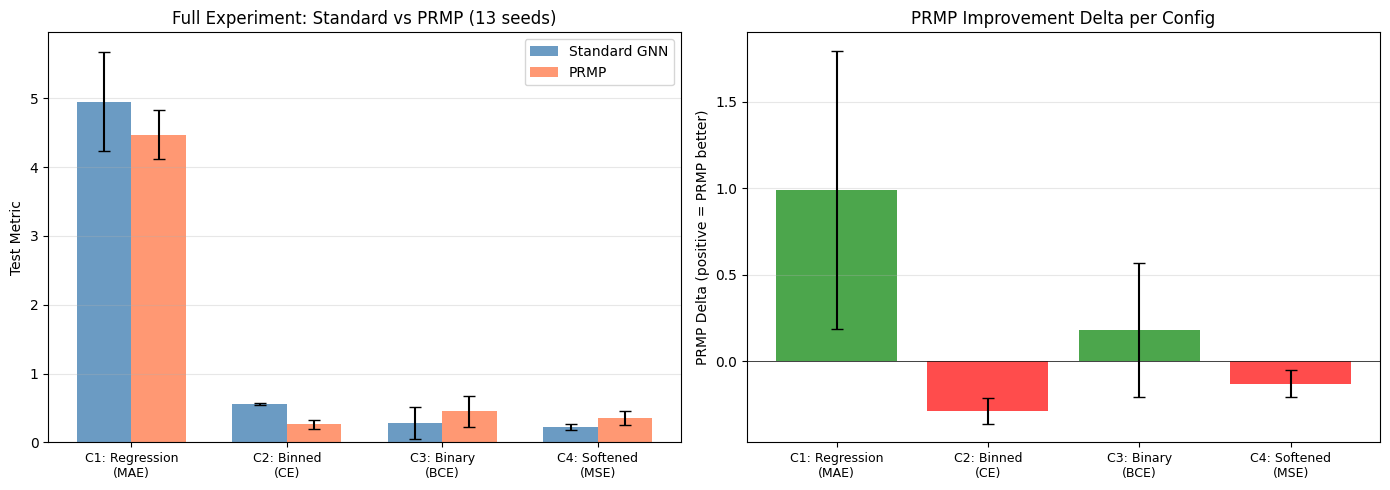


FULL EXPERIMENT RESULTS (pre-computed, 13 seeds x 80 epochs)
Config                                Std Metric  PRMP Metric      Delta
----------------------------------------------------------------------
config1_natural_regression                4.9554       4.4751    +0.9879
config2_binned_classification             0.5556       0.2646    -0.2882
config3_natural_classification            0.2760       0.4508    +0.1816
config4_softened_regression               0.2252       0.3514    -0.1300

Loss-function hypothesis: p=0.0084 (significant)
Target-nature hypothesis: p=0.0824 (significant)

Conclusion: Mixed

LIVE DEMO RESULTS (1 seed(s) x 10 epochs)
  config1_natural_regression | standard | seed_42: 12.807910919189453
  config1_natural_regression |     prmp | seed_42: 12.736737251281738
  config2_binned_classification | standard | seed_42: 0.2857142857142857
  config2_binned_classification |     prmp | seed_42: 0.12698412698412698
  config3_natural_classification | standard | seed_42:

In [9]:
# Parse pre-computed results
precomputed = data
pre_analysis = precomputed["metadata"]["analysis"]
pre_examples = precomputed["datasets"][0]["examples"]

from collections import defaultdict
pre_metrics = defaultdict(lambda: {"standard": [], "prmp": []})
for ex in pre_examples:
    cn = ex["metadata_config"]
    out = json.loads(ex["output"])
    pre_metrics[cn]["standard"].append(out["standard_test_metric"])
    pre_metrics[cn]["prmp"].append(out["prmp_test_metric"])

config_names_short = {
    "config1_natural_regression": "C1: Regression\n(MAE)",
    "config2_binned_classification": "C2: Binned\n(CE)",
    "config3_natural_classification": "C3: Binary\n(BCE)",
    "config4_softened_regression": "C4: Softened\n(MSE)",
}

# ── Figure: PRMP Delta per Config ──
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

config_order = sorted(pre_metrics.keys())
x_pos = np.arange(len(config_order))
width = 0.35

# Left: Standard vs PRMP metrics
ax = axes[0]
std_means = [np.mean(pre_metrics[cn]["standard"]) for cn in config_order]
prmp_means = [np.mean(pre_metrics[cn]["prmp"]) for cn in config_order]
std_stds = [np.std(pre_metrics[cn]["standard"]) for cn in config_order]
prmp_stds = [np.std(pre_metrics[cn]["prmp"]) for cn in config_order]

ax.bar(x_pos - width/2, std_means, width, yerr=std_stds, label="Standard GNN",
       color="steelblue", alpha=0.8, capsize=4)
ax.bar(x_pos + width/2, prmp_means, width, yerr=prmp_stds, label="PRMP",
       color="coral", alpha=0.8, capsize=4)
ax.set_xticks(x_pos)
ax.set_xticklabels([config_names_short.get(cn, cn) for cn in config_order], fontsize=9)
ax.set_ylabel("Test Metric")
ax.set_title("Full Experiment: Standard vs PRMP (13 seeds)")
ax.legend()
ax.grid(axis="y", alpha=0.3)

# Right: PRMP deltas
ax = axes[1]
deltas_pre = pre_analysis["deltas_per_config"]
delta_means = [deltas_pre[cn]["mean"] for cn in config_order]
delta_stds = [deltas_pre[cn]["std"] for cn in config_order]
colors = ["green" if d > 0 else "red" for d in delta_means]

ax.bar(x_pos, delta_means, yerr=delta_stds, color=colors, alpha=0.7, capsize=4)
ax.axhline(y=0, color="black", linestyle="-", linewidth=0.5)
ax.set_xticks(x_pos)
ax.set_xticklabels([config_names_short.get(cn, cn) for cn in config_order], fontsize=9)
ax.set_ylabel("PRMP Delta (positive = PRMP better)")
ax.set_title("PRMP Improvement Delta per Config")
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig("results_visualization.png", dpi=100, bbox_inches="tight")
plt.show()

# ── Summary Table ──
print("\n" + "="*70)
print("FULL EXPERIMENT RESULTS (pre-computed, 13 seeds x 80 epochs)")
print("="*70)
print(f"{'Config':<35} {'Std Metric':>12} {'PRMP Metric':>12} {'Delta':>10}")
print("-"*70)
for cn in config_order:
    sm = np.mean(pre_metrics[cn]["standard"])
    pm = np.mean(pre_metrics[cn]["prmp"])
    d = deltas_pre[cn]["mean"]
    print(f"{cn:<35} {sm:>12.4f} {pm:>12.4f} {d:>+10.4f}")

print(f"\nLoss-function hypothesis: p={pre_analysis['loss_function_hypothesis']['p_value']:.4f} "
      f"({'significant' if pre_analysis['loss_function_hypothesis']['effect_significant'] else 'not significant'})")
print(f"Target-nature hypothesis: p={pre_analysis['target_nature_hypothesis']['p_value']:.4f} "
      f"({'significant' if pre_analysis['target_nature_hypothesis']['effect_significant'] else 'not significant'})")
print(f"\nConclusion: {pre_analysis['conclusion']}")

# Show live results if available
if live_results:
    print("\n" + "="*70)
    print(f"LIVE DEMO RESULTS ({len(SEEDS)} seed(s) x {EPOCHS} epochs)")
    print("="*70)
    for cn in sorted(live_results.keys()):
        for meth in ["standard", "prmp"]:
            for sk, res in live_results[cn][meth].items():
                m = res.get('test_metric', 'N/A')
                print(f"  {cn} | {meth:>8} | {sk}: {m}")